# Macrostrat stratigraphic columns: lithology-styled paleogeologic maps


**Cluster G: Paleo-geography + paleo-topography.**

*Contributed by:* Daven Quinn and Shanan E. Peters (Department of Geoscience, University of Wisconsin-Madison) — creators of [Macrostrat](https://macrostrat.org/) and authors of the source demo this notebook adapts.

**Reconstruct Macrostrat's stratigraphic column footprints to their paleo-position and progressively style them — flat API colour, then colours blended across each column's mixed lithology, then GMT lithology-pattern fills.** Adapted from the [UW-Macrostrat / GPlately + pyGMT demo](https://github.com/UW-Macrostrat/gplately-pygmt-demo), which itself grew out of this suite's own **T01 — Hello, deep time**.

## What this notebook produces

Four maps of Laurentia (North America) at 400 Ma (Early Devonian): (1) present-day Macrostrat column footprints for North America, unrotated, as a sanity check; (2) the same columns rotated to 400 Ma and overlaid on a reconstructed paleogeographic basemap; (3) three progressively richer stylings of the *paleo-positioned* columns — flat Macrostrat API colour, mixed-lithology-proportion colour blending, and GMT pattern fills keyed to each column's dominant lithology — plus a pattern key.

## What you will learn

1. How to pull polygon and tabular data from a **live REST API** (Macrostrat, `/columns`, `/units`, `/defs/lithologies`) and turn it into a `geopandas.GeoDataFrame`.
2. How to rotate arbitrary present-day polygon footprints — not a bundled GPlately/GPlates dataset — back through time with `pygplates.partition_into_plates`, keeping each footprint intact via `PartitionMethod.most_overlapping_plate`.
3. How to fill many polygons with per-row categorical colours or GMT patterns in a single `pygmt.Figure.choropleth` call, by writing a small categorical CPT on the fly.
4. How to blend several lithology colours by area-weighted proportion (a Python port of Macrostrat's own [`column-views` colour-mixing code](https://github.com/UW-Macrostrat/web-components/blob/main/packages/column-views/src/units/colors.ts)) using `coloraide`.

**Audience**: intermediate — comfortable with T01's GPlately + pyGMT plumbing, now applied to a dataset that Macrostrat serves live rather than a suite-bundled model layer.
**Prerequisites**: a `gplately` conda environment that also includes `pygmt` and `coloraide` (`pip install coloraide` / `conda install -c conda-forge coloraide`). Internet access is required — both for `plate_model_manager` (plate model download, cached after first run) and for live calls to the Macrostrat API on every run (Macrostrat's column/unit/lithology data changes over time, so we don't bundle a static copy).
**Runtime**: ≈1–2 minutes on first run (plate-model download + several Macrostrat API calls); ≈20–30 seconds thereafter.

## Learning objectives

- Fetch polygon and tabular data from Macrostrat's live REST API and load it as a `GeoDataFrame`.
- Rotate non-GPlately present-day footprints back through time with `pygplates.partition_into_plates` + `PlateReconstruction.reconstruct`.
- Fill many polygons with per-row colours or patterns in one `pygmt.Figure.choropleth` call via an on-the-fly categorical CPT.
- Blend lithology colours by proportion and key GMT predefined patterns to dominant lithology.
- Recognise the continuous-backbone pattern for drawing complete plate-boundary networks (shared with T01 and the rest of the suite).

## Prerequisites and runtime

- **Plate model**: Zahirovic 2022 (suite default; the source demo used Merdith 2021 — see the *Configuration* section below for why we default differently here).
- **Reconstruction time**: 400 Ma (Early Devonian), matching the source demo.
- **Region**: Macrostrat `project_id=1` (North America / Laurentia).
- **Python**: `gplately`, `pygmt`, `pygplates`, `plate_model_manager`, `geopandas`, `pandas`, `coloraide`.
- **Runtime**: ≈1–2 minutes on first run (plate-model download + Macrostrat API calls); ≈20–30 seconds thereafter. No data is bundled or cached to disk beyond the plate model itself — every run queries Macrostrat live.

In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports and version check
import gplately
import geopandas as gpd
import pandas as pd
import pygmt
from coloraide import Color
from plate_model_manager import PlateModelManager

print(f"gplately         {gplately.__version__}")
print(f"geopandas        {gpd.__version__}")
print(f"pandas           {pd.__version__}")

# Suite-wide tutorial style: bigger panel titles, 1cm gap between figures.
pygmt.config(FONT_TITLE="18p", FONT_LABEL="18p",
             FONT_ANNOT_PRIMARY="14p")
print(f"pygmt            {pygmt.__version__}")
print()
print("Full pyGMT / GMT stack:")
pygmt.show_versions()

gplately         2.0.0
geopandas        1.1.4
pandas           3.0.2
pygmt            v0.17.0

Full pyGMT / GMT stack:
PyGMT information:
  version: v0.17.0
System information:
  python: 3.11.15 (main, Mar  3 2026, 09:26:23) [GCC 13.3.0]
  executable: /usr/bin/python3
  machine: Linux-6.18.5-fc-v20-x86_64-with-glibc2.39
Dependency information:
  numpy: 2.4.4
  pandas: 3.0.2
  xarray: 2026.7.0
  packaging: 26.1
  contextily: None
  geopandas: 1.1.4
  IPython: 9.15.0
  pyarrow: 25.0.0
  rioxarray: 0.19.0
  gdal: None
  ghostscript: 10.02.1
GMT library information:
  version: 6.5.0
  padding: 2
  share dir: /usr/share/gmt
  plugin dir: /usr/lib/x86_64-linux-gnu/gmt/plugins
  library path: /usr/lib/x86_64-linux-gnu/libgmt.so
  cores: 2
  grid layout: rows
  image layout: 
  binary version: 6.5.0


## Configuration

User-tunable choices for this notebook. Edit the values below to change the model, snapshot time, Macrostrat project, or region without hunting through downstream code.

**A note on `MODEL_NAME`.** The upstream UW-Macrostrat demo uses **Merdith et al. (2021)**, which reaches back to 1 Ga and is a natural choice for a notebook that might be pointed at much older Macrostrat columns elsewhere on the globe. This suite's own default is **Zahirovic et al. (2022)**, which covers 0–410 Ma — 400 Ma sits right at the edge of that range, so it still works here, and using it keeps this notebook consistent with the rest of the suite. There is no grid-data-pairing constraint forcing one model over the other (unlike, say, a bundled dynamic-topography or paleo-DEM raster that was itself computed under a specific model): Macrostrat's column and unit polygons are plain present-day geometries fetched live, so any published rotation model can reconstruct them. Switch `MODEL_NAME` to `"Merdith2021"` to reproduce the upstream demo's exact frame, or to push `AGE` past 410 Ma for other Macrostrat projects.

In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME       = "Zahirovic2022"   # suite default; try "Merdith2021" for >410 Ma
AGE              = 400.0             # Ma — Early Devonian, matches the source demo
ANCHOR_PLATE_ID  = 0                 # 0 = mantle reference frame
PROJECT_ID       = 1                 # Macrostrat project_id — 1 = North America
AGE_SPAN         = 5.0               # Myr window (± half) for "units active at AGE"
# ============================================================================

## 1. Load the plate model and set up reconstruction + basemap helpers

Same pattern as **T01**: fetch the model via `plate_model_manager`, build a `gplately.PlateReconstruction` and a `gplately.PlotTopologies` snapshot pinned at `AGE`, and wrap the common basemap boilerplate (frame, continents, coastlines, continuous plate-boundary backbone, styled ridges/transforms/trenches) in a reusable function.

In [3]:
# Cell 2 — fetch the plate model, build PlateReconstruction + PlotTopologies @ AGE
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")

reconstruction_model = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)

gplot = gplately.PlotTopologies(
    plate_reconstruction=reconstruction_model,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(AGE),
    plot_engine=gplately.PygmtPlotEngine(),
)

print(f"Reconstruction time: {gplot.time} Ma  ({MODEL_NAME})")


def time_stamp(fig, age=AGE, model_name=MODEL_NAME):
    """In-frame '{age} Ma (model)' stamp, drawn as the LAST layer on `fig`."""
    label = f"{age:.0f} Ma  ({model_name})" if age else f"Present day  ({model_name})"
    fig.text(text=label, position="TL", offset="0.25c/-0.25c", justify="TL",
              font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")


def reconstruction_basemap(title, region="d", projection="N0/20c", age=AGE):
    """A paleogeographic basemap at `age` — continents, coastlines, and the
    continuous plate-boundary backbone with styled ridges/transforms/trenches
    on top, matching the house pattern used throughout the suite (see T01)."""
    fig = pygmt.Figure()
    fig.basemap(region=region, projection=projection,
                frame=["af", f"+t{title}"])
    gplot.plot_continents(fig, fill="gray95", pen="0.2p,gray30")
    gplot.plot_coastlines(fig, pen="0.4p,gray20")
    # Continuous backbone first (catches "other" connection segments), then
    # the styled ridge/transform/trench layers on top — see T01 for the
    # rationale.
    gplot.plot_all_topological_sections(fig, pen="0.5p,gray50")
    gplot.plot_ridges(fig, pen="0.6p,red")
    gplot.plot_transforms(fig, pen="0.5p,goldenrod")
    gplot.plot_subduction_teeth(fig, color="blue")
    return fig

Reconstruction time: 400.0 Ma  (Zahirovic2022)


## 2. Macrostrat columns

[Macrostrat](https://macrostrat.org/) is a community stratigraphic database — a "column" is a location where geologists have logged a vertical succession of rock units. Its [v2 API](https://macrostrat.org/api/v2) serves column footprints, per-unit metadata, and lithology definitions, each wrapped in a `{"success": {"data": ...}}` envelope.

[Columns](https://macrostrat.org/api/v2/columns?project_id=1&format=geojson) come back as a GeoJSON `FeatureCollection`, which `geopandas.GeoDataFrame.from_features` reads directly.

949 Macrostrat columns in project 1 (North America)


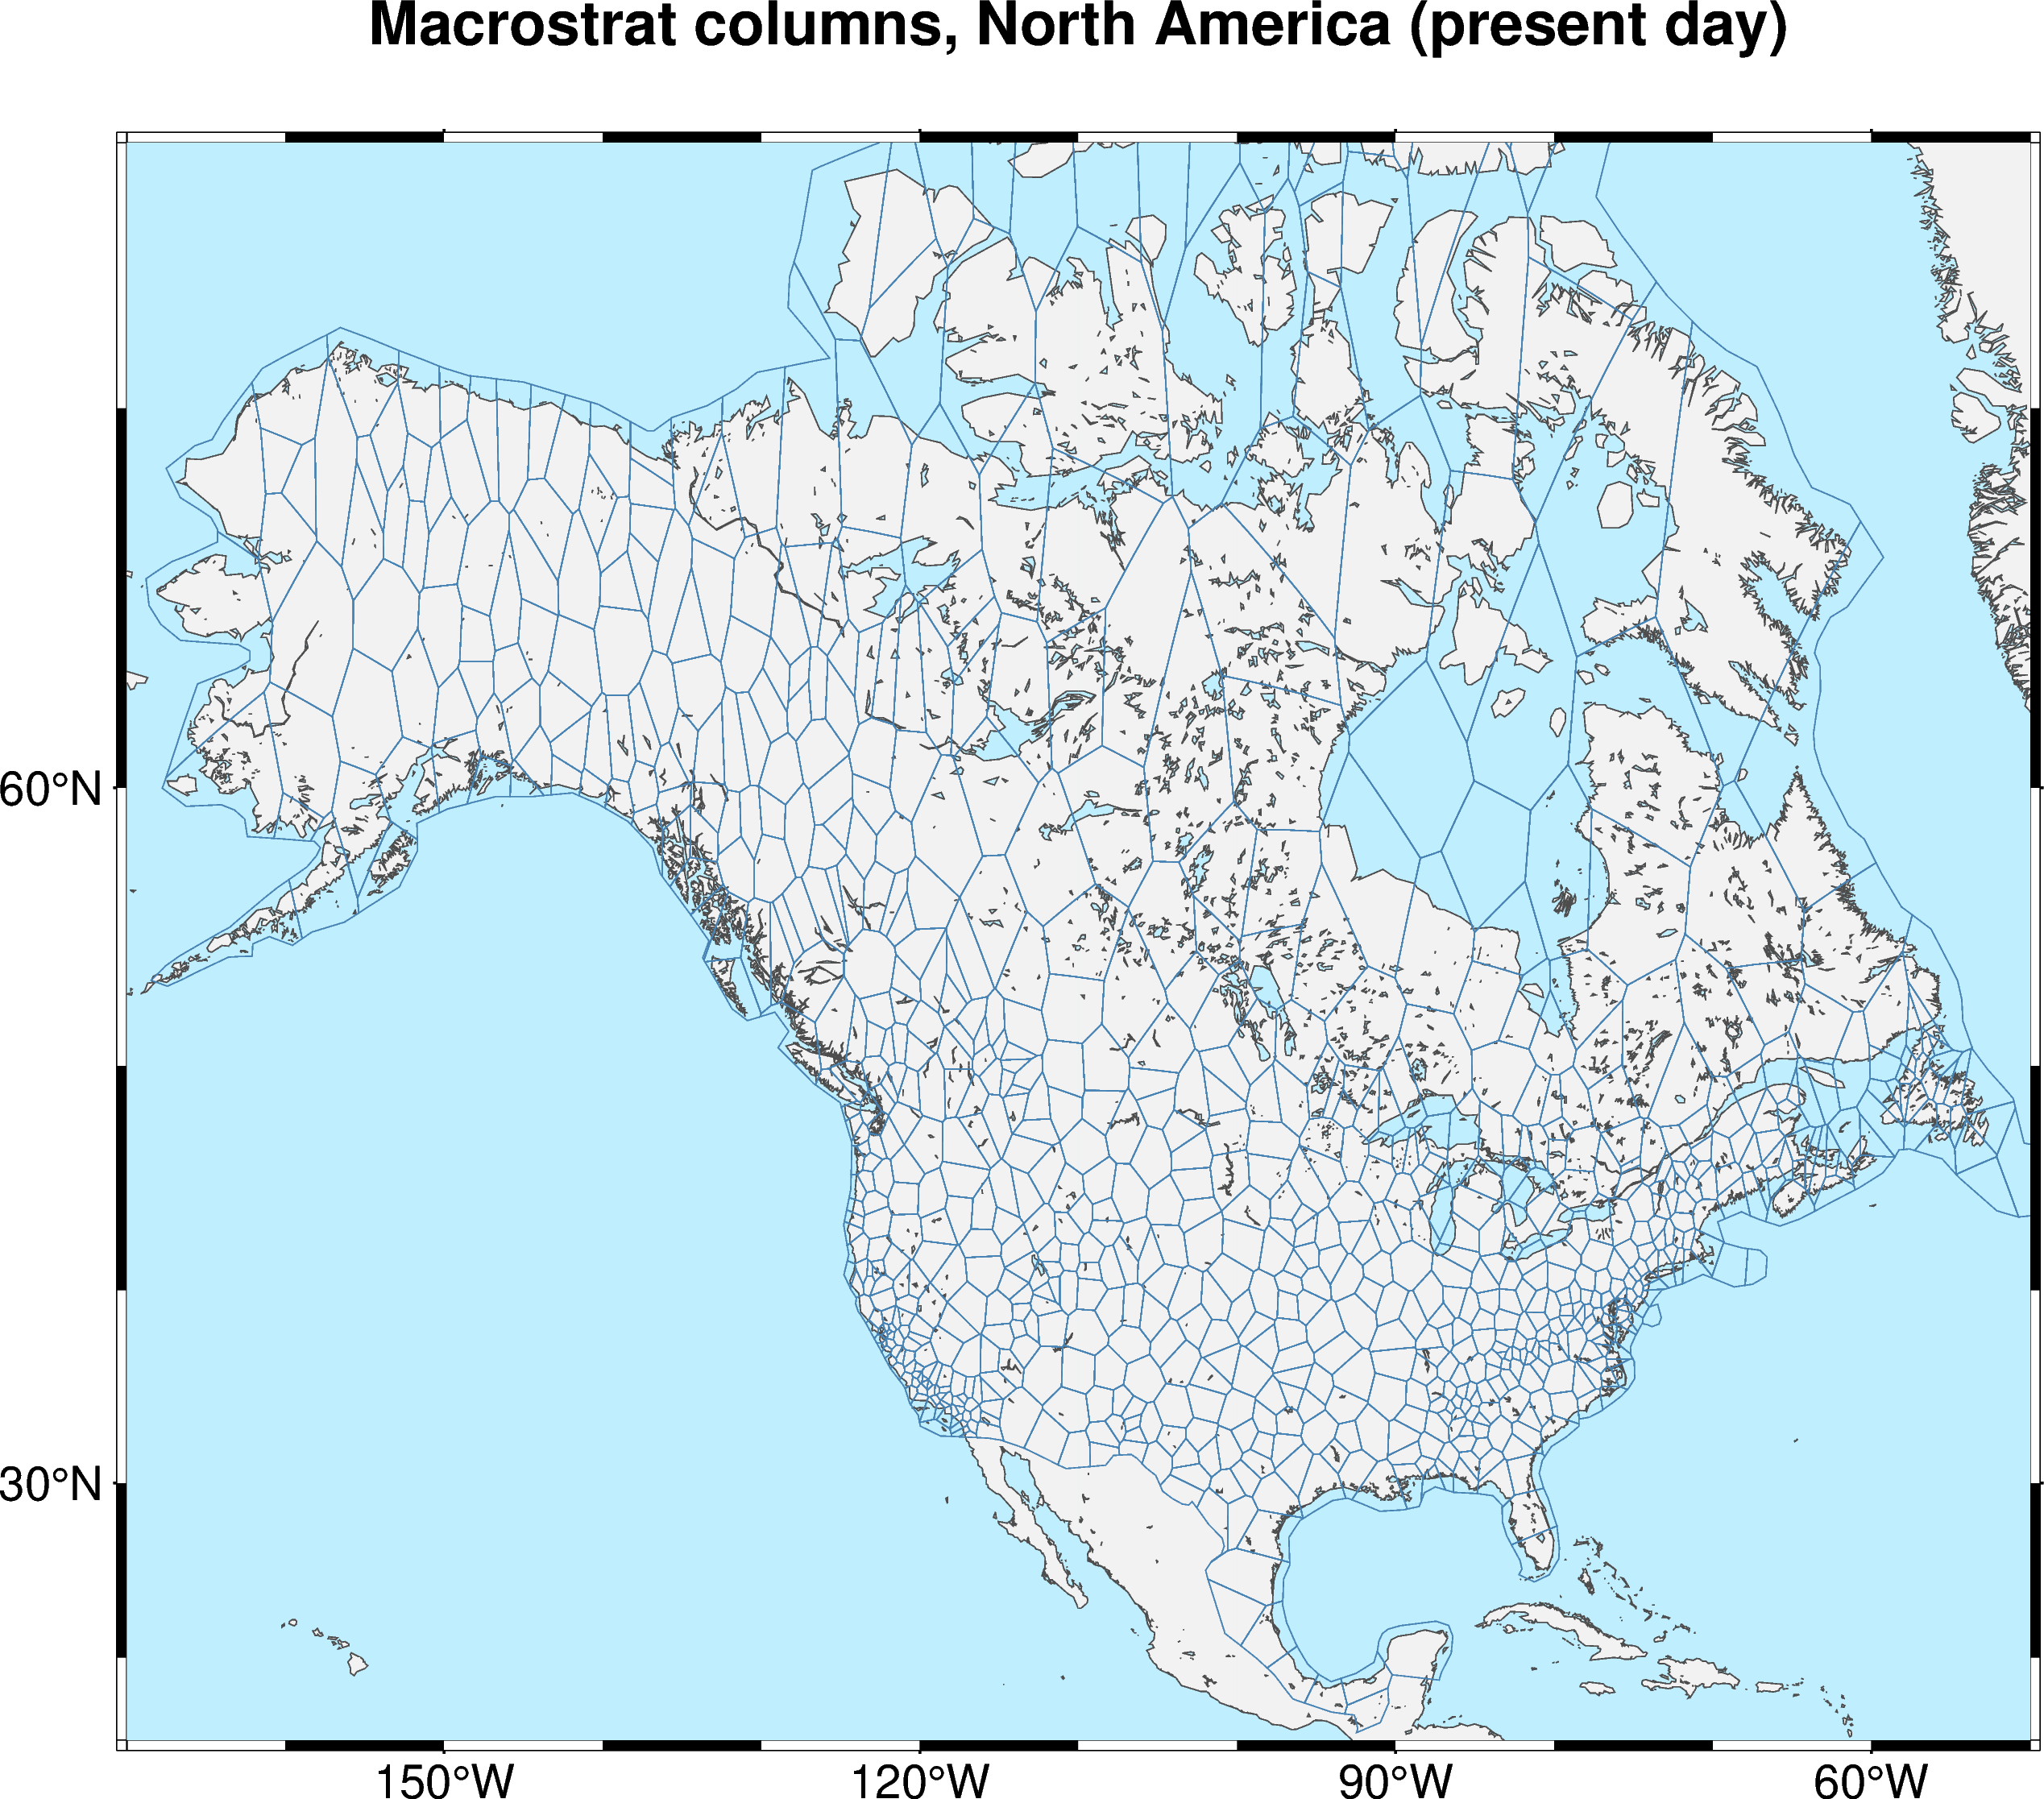

In [4]:
# Cell 3 — Macrostrat API helper + column footprints for PROJECT_ID
from urllib.parse import urlencode
from urllib.request import urlopen
from json import load as json_load

MACROSTRAT_ROOT_URL = "https://macrostrat.org/api/v2"


def get_macrostrat_data(path, **params):
    """GET a Macrostrat v2 endpoint, unwrapping the "success" envelope."""
    query_params = {k: v for k, v in params.items() if v is not None}
    query = urlencode(query_params)
    with urlopen(f"{MACROSTRAT_ROOT_URL}/{path}?{query}") as response:
        body = json_load(response)
    return body["success"]["data"]


def get_macrostrat_columns(project_id=None):
    """Column footprints as a GeoDataFrame, one row per column."""
    params = dict(project_id=project_id)
    if project_id is None:
        params["all"] = 1
    collection = get_macrostrat_data("columns", format="geojson", **params)
    return gpd.GeoDataFrame.from_features(collection["features"], crs="EPSG:4326")


na_columns = get_macrostrat_columns(project_id=PROJECT_ID)
print(f"{len(na_columns)} Macrostrat columns in project {PROJECT_ID} (North America)")

# Present-day sanity check — no reconstruction involved yet.
fig = pygmt.Figure()
fig.basemap(region=[-170, -50, 15, 75], projection="M20c",
            frame=["af", "+tMacrostrat columns, North America (present day)"])
fig.coast(land="gray95", water="lightblue1", shorelines="0.3p,gray30")
fig.plot(data=na_columns, pen="0.3p,steelblue")
fig.show(width=900)

### What the present-day map shows

Every polygon Macrostrat currently indexes for project 1 — dense along the well-studied margins and interior basins of the United States and Canada, sparser in less-drilled or less-outcropping terrain. This is our starting footprint set, in its present-day position, before any plate reconstruction.

## 3. Rotating Macrostrat columns back to 400 Ma

Macrostrat's column footprints are ordinary present-day polygons — not a GPlately/GPlates-native dataset — so rotating them needs one extra step beyond what `PlotTopologies` gives us for free: assign each footprint to a plate, then reconstruct.

`pygplates.partition_into_plates` does the assignment. We use `PartitionMethod.most_overlapping_plate` so a column that straddles a plate boundary stays intact (assigned whole to whichever plate covers more of it) rather than being split into fragments — appropriate here since we care about each column's overall paleo-position, not sub-column deformation.

949 columns reconstructed to 400 Ma


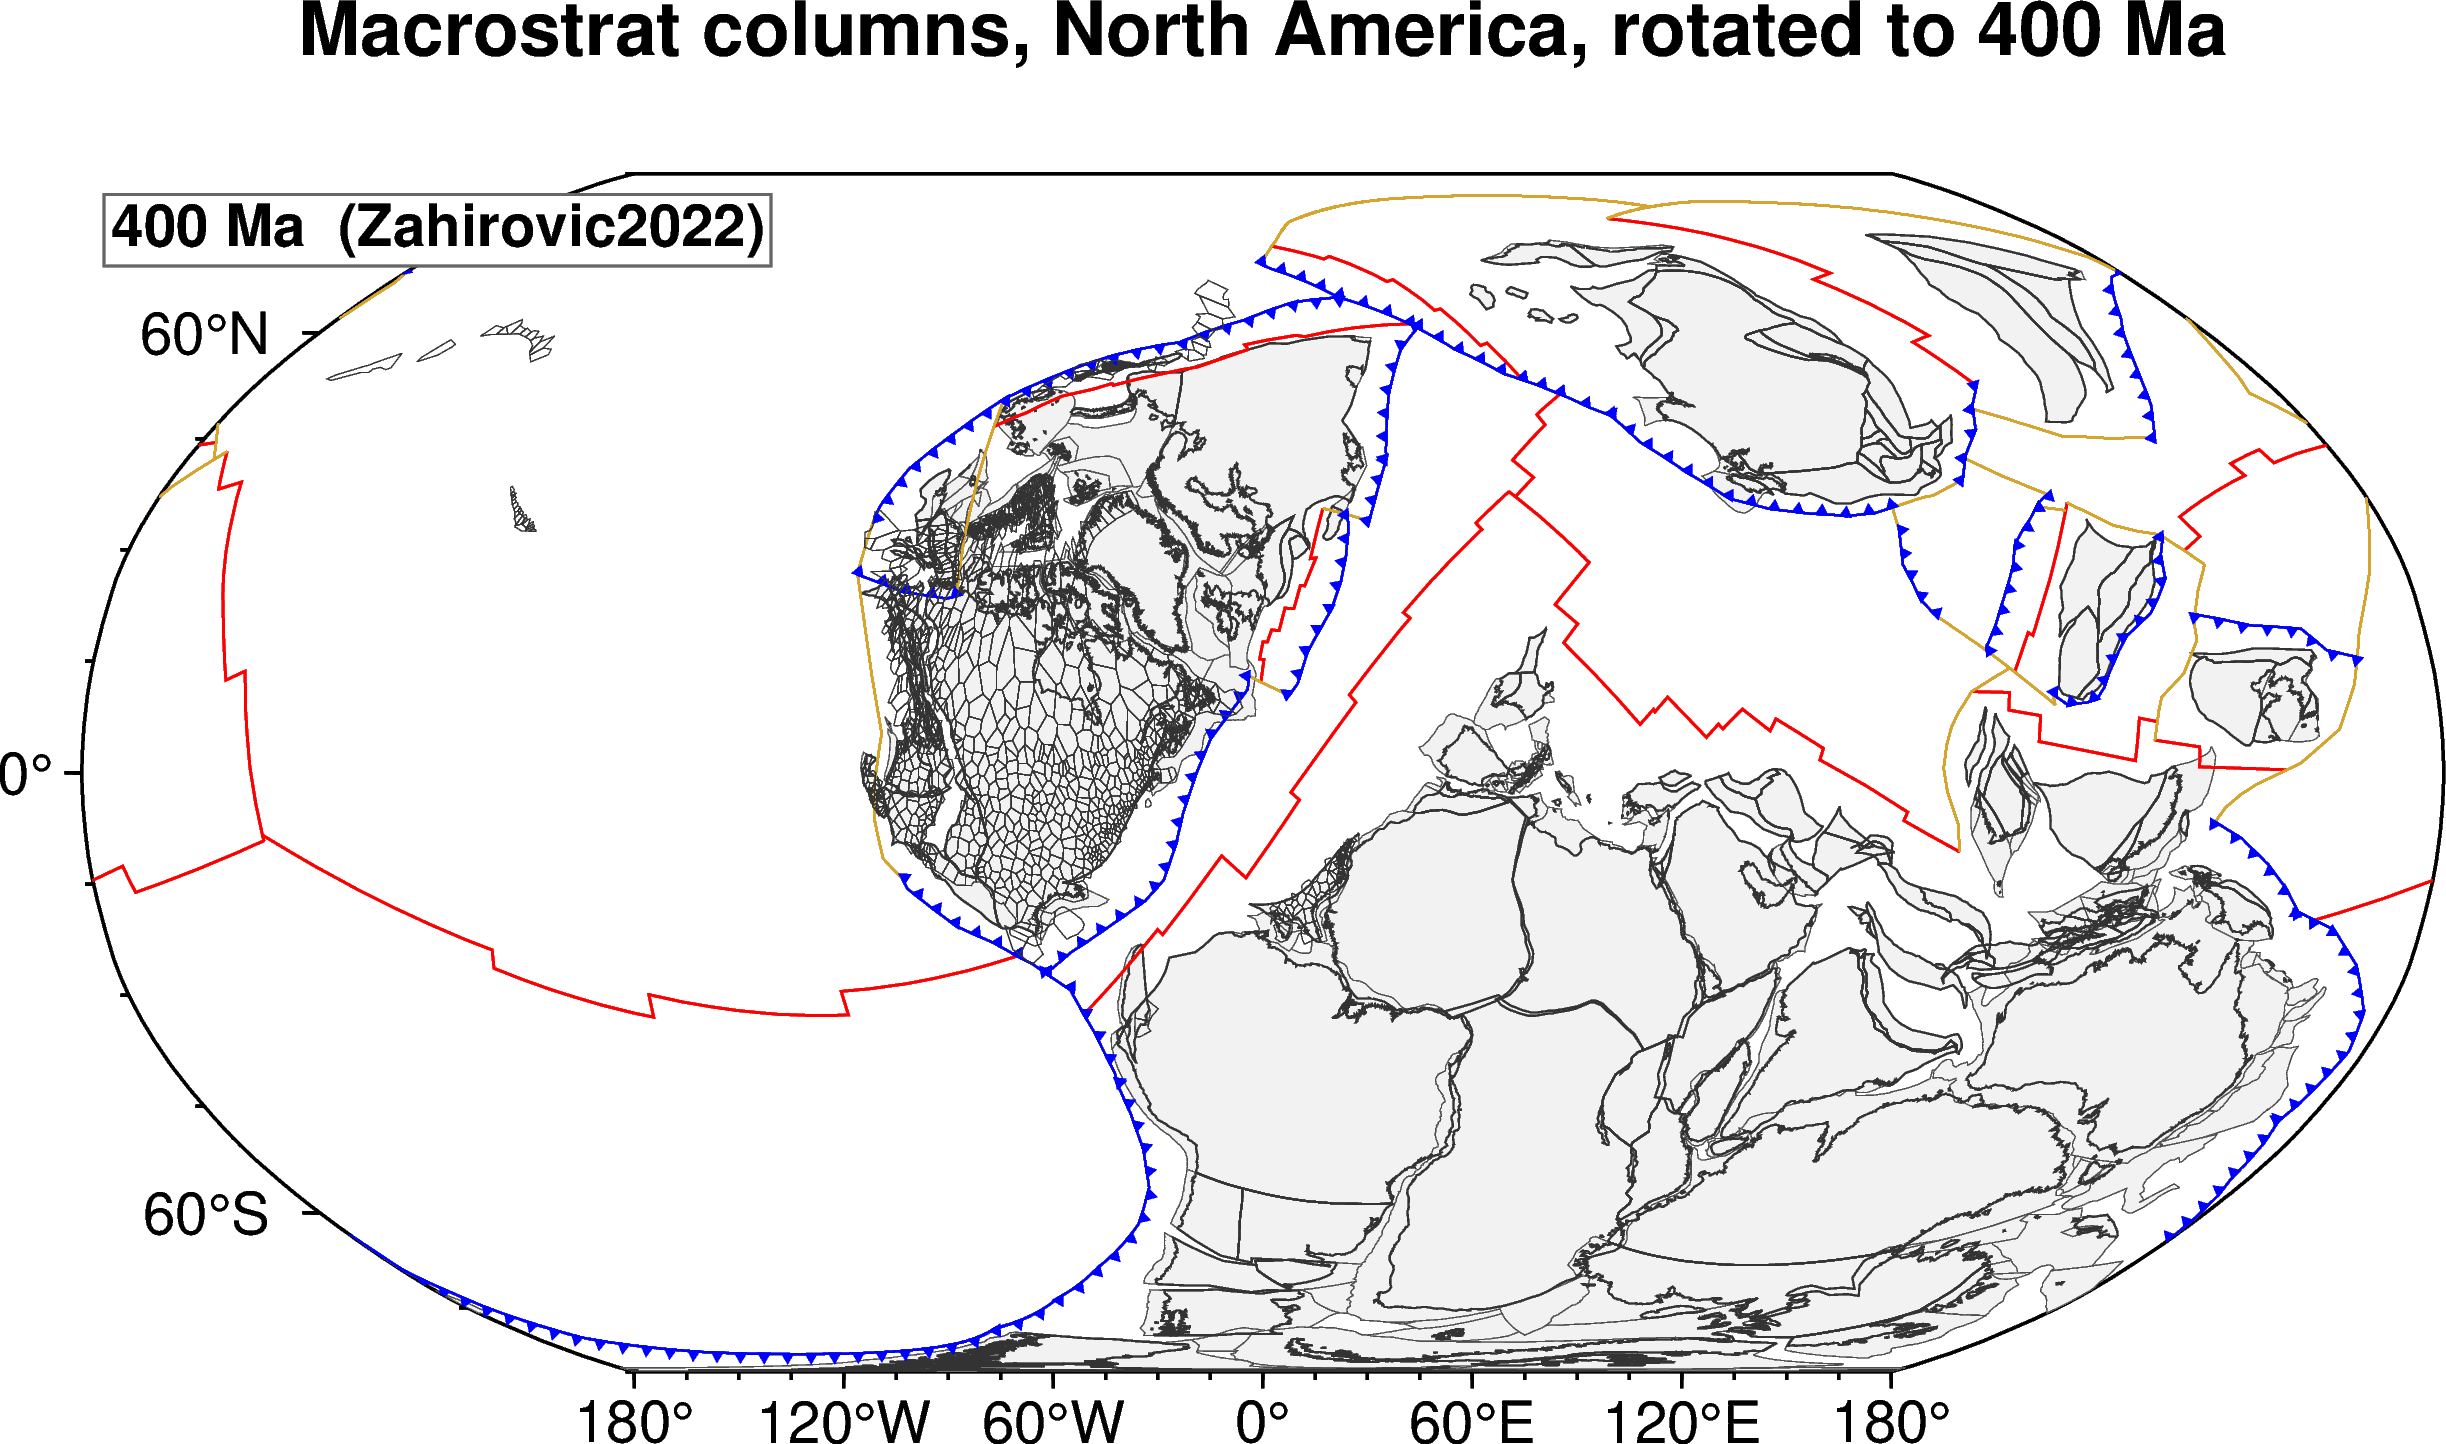

In [5]:
# Cell 4 — rotate column footprints to AGE via partition_into_plates
from gplately.geometry import pygplates_to_shapely, shapely_to_pygplates
from pygplates import Feature, PartitionMethod, partition_into_plates


def _column_to_feature(col_id, geometry):
    feature = Feature()
    feature.set_geometry(shapely_to_pygplates(geometry))
    feature.set_name(str(col_id))  # carries col_id through the rotation
    return feature


def reconstruct_columns(columns, age_ma):
    """Rotate column footprints to `age_ma` under `reconstruction_model`."""
    features = [
        _column_to_feature(row.col_id, row.geometry)
        for row in columns.itertuples()
    ]

    partitioned = partition_into_plates(
        reconstruction_model.static_polygons,
        reconstruction_model.rotation_model,
        features,
        reconstruction_time=0,
        # Keep each column intact instead of splitting it across plate boundaries.
        partition_method=PartitionMethod.most_overlapping_plate,
    )

    rotated = gpd.GeoDataFrame(
        [
            {
                "col_id": int(rec.get_feature().get_name()),
                "plate_id": rec.get_feature().get_reconstruction_plate_id(),
                "geometry": pygplates_to_shapely(rec.get_reconstructed_geometry()),
            }
            for rec in reconstruction_model.reconstruct(
                partitioned, age_ma, anchor_plate_id=ANCHOR_PLATE_ID
            )
        ],
        geometry="geometry",
        crs="EPSG:4326",
    )
    # Rejoin the Macrostrat attributes to the rotated geometry.
    return rotated.merge(columns.drop(columns="geometry"), on="col_id")


reconstructed_cols = reconstruct_columns(na_columns, AGE)
print(f"{len(reconstructed_cols)} columns reconstructed to {AGE:.0f} Ma")

fig = reconstruction_basemap(f"Macrostrat columns, North America, rotated to {AGE:.0f} Ma")
fig.plot(data=reconstructed_cols, pen="0.2p,gray20")
time_stamp(fig)
fig.show(width=900)

### What the rotated map shows

The same footprints as the present-day map, now rotated to their 400 Ma position on Laurentia — clustered close to the paleo-equator, well south of where they sit today, consistent with Laurentia's Devonian paleogeography. Next we zoom to a regional view and start adding real stratigraphic content.

## 4. A regional view of Laurentia

The global basemap above wastes most of its area on empty ocean. We switch to a Lambert azimuthal equal-area projection zoomed on Laurentia — but *where* Laurentia sits at 400 Ma depends on which plate model is in play (the source demo's hardcoded region was tuned to Merdith 2021's frame; it crops most of the continent under Zahirovic 2022's, since the two models' 400 Ma frames don't agree on the raw mantle-frame longitude). Rather than hardcode a region that only suits one `MODEL_NAME`, we derive it from the reconstruction itself: take the **dominant reconstruction plate ID** among our columns (the craton the bulk of them reconstruct onto — plate 101, cratonic Laurentia, under Zahirovic 2022) and frame the map on that plate's rotated bounding box, padded by 25%.

This has a side benefit worth noticing: a minority of present-day "North America" Macrostrat columns sit on **accreted terranes** — western-margin blocks (Cordilleran terranes, island arcs, etc.) that had not yet docked onto Laurentia at 400 Ma, and so reconstruct to a plate ID (and a paleo-position) far from the craton. Framing on the dominant plate deliberately crops most of these out; see *Extend this* for how to show them instead.

504/949 columns reconstruct onto plate 101 (the dominant craton) — framing the regional map on these


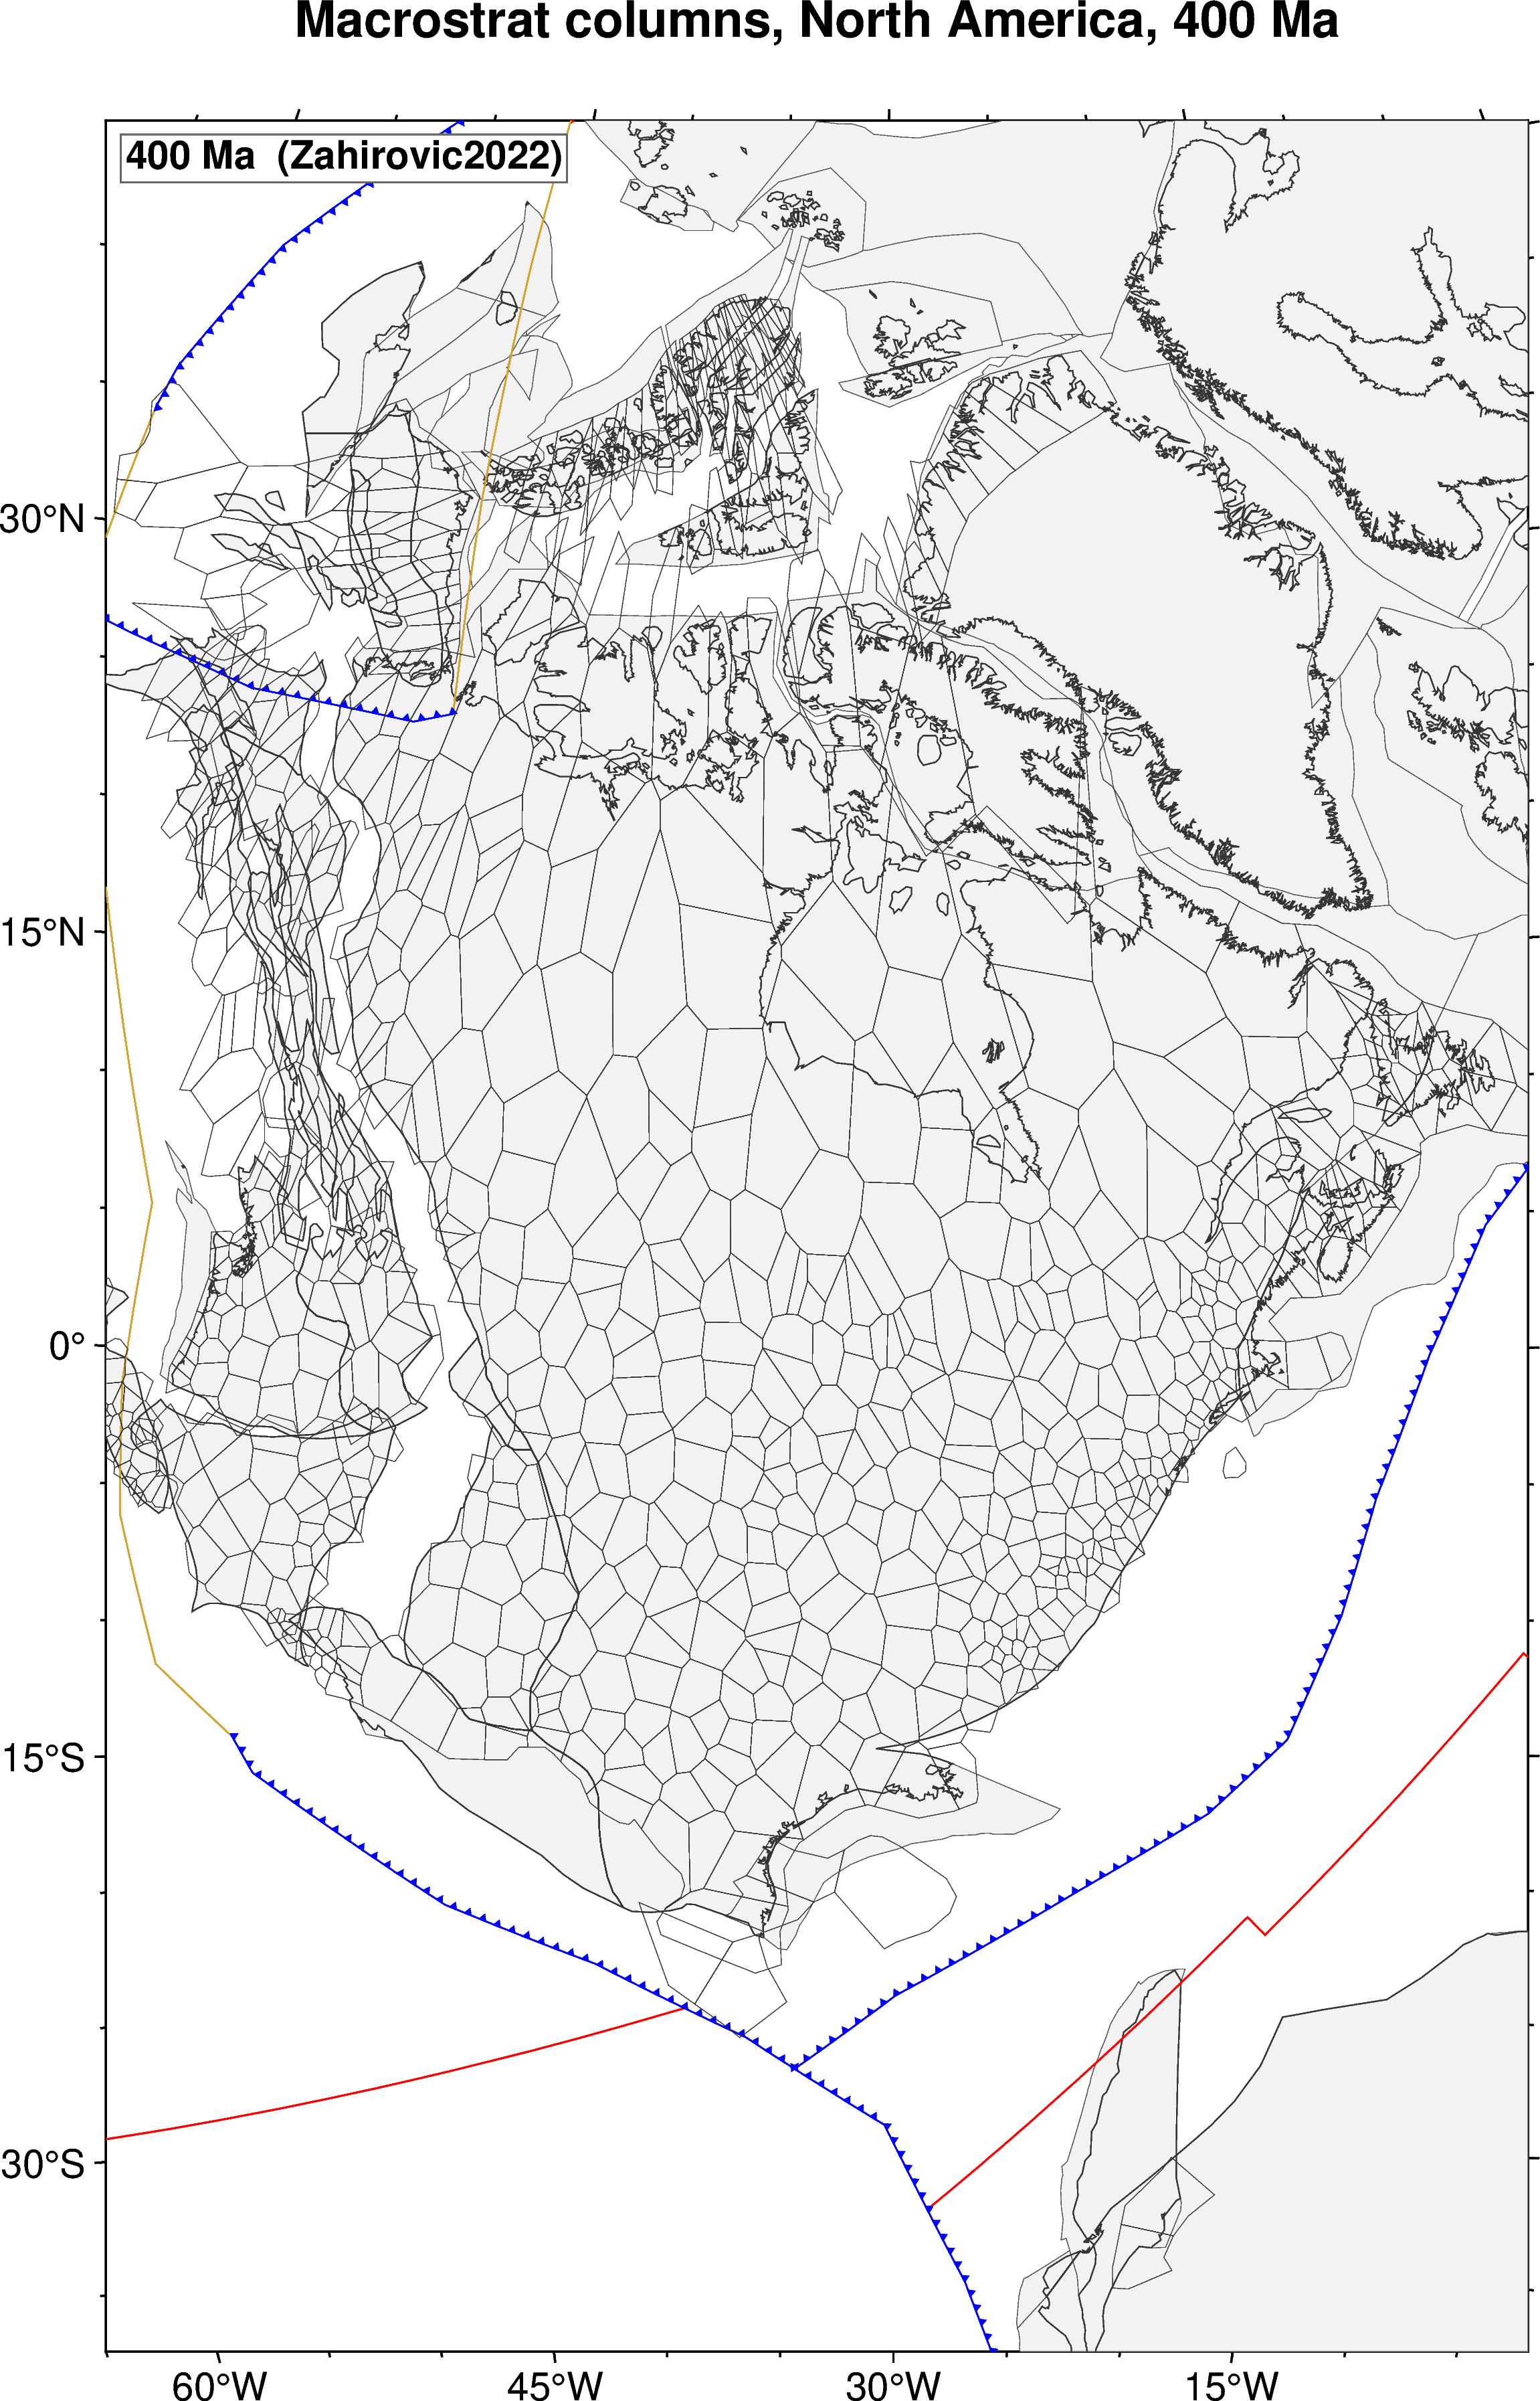

In [6]:
# Cell 5 — regional Lambert-azimuthal projection, framed on the dominant plate
dominant_plate_id = reconstructed_cols["plate_id"].value_counts().idxmax()
core_cols = reconstructed_cols[reconstructed_cols["plate_id"] == dominant_plate_id]
print(f"{len(core_cols)}/{len(reconstructed_cols)} columns reconstruct onto "
      f"plate {dominant_plate_id} (the dominant craton) — framing the regional "
      f"map on these")

minx, miny, maxx, maxy = core_cols.total_bounds
pad_x, pad_y = 0.25 * (maxx - minx), 0.25 * (maxy - miny)
west, east = minx - pad_x, maxx + pad_x
south, north = miny - pad_y, maxy + pad_y

# Azimuthal projections take the region as corners, hence the "+r".
REGION = f"{west:.1f}/{south:.1f}/{east:.1f}/{north:.1f}+r"

lon0, lat0 = (west + east) / 2, (south + north) / 2
width = "18c"        # paper width of the output
horizon = 90          # degrees from the projection centre to render
PROJECTION = f"A{lon0:.1f}/{lat0:.1f}/{horizon}/{width}"


def regional_basemap(title):
    return reconstruction_basemap(title, region=REGION, projection=PROJECTION)


fig = regional_basemap(f"Macrostrat columns, North America, {AGE:.0f} Ma")
fig.plot(data=reconstructed_cols, pen="0.2p,gray20")
time_stamp(fig)
fig.show(width=750)

## 5. Which columns were actively depositing at 400 Ma?

The column footprints above show *where Macrostrat has data*, but not *what was being deposited when*. To see actual depositional extent at `AGE`, we query Macrostrat's [Units API](https://macrostrat.org/api/v2/units) for every unit whose age range overlaps `AGE ± AGE_SPAN/2` — a small window to absorb age-model uncertainty.

A column can hold several qualifying units at once; for now we keep it simple with `drop_duplicates` and take one unit per column (the *"Extend this"* section suggests a fuller treatment).

In [7]:
# Cell 6 — units active in the AGE window, one per column
def get_macrostrat_units(age_ma, age_span=0.0, project_id=None):
    """Every unit whose age range spans `age_ma` ± `age_span` / 2."""
    d_age = age_span / 2
    units = get_macrostrat_data(
        "units",
        age_bottom=age_ma + d_age,
        age_top=age_ma - d_age,
        response="long",
        project_id=project_id,
    )
    return pd.DataFrame(units)


na_units = get_macrostrat_units(AGE, age_span=AGE_SPAN, project_id=PROJECT_ID)
print(f"{len(na_units)} units in {na_units['col_id'].nunique()} columns "
      f"active at {AGE:.0f} ± {AGE_SPAN/2:.1f} Ma")

one_unit_per_column = na_units.drop_duplicates(subset="col_id")
units_colored_by_api = reconstructed_cols.merge(
    one_unit_per_column[["col_id", "color"]], on="col_id"
).rename(columns={"color": "fill"})
print(f"{len(units_colored_by_api)} columns have an actively-depositing unit "
      f"in this window")

394 units in 302 columns active at 400 ± 2.5 Ma
302 columns have an actively-depositing unit in this window


### Styling individual polygons

`fig.plot(fill=...)` takes a single paint value per call, so it can't vary fill row-by-row on its own — and not every pyGMT release ships [`Figure.choropleth`](https://www.pygmt.org/latest/api/generated/pygmt.Figure.choropleth.html) (added in a later release than this suite's minimum pyGMT version), so we don't depend on it here. Instead we group columns that share an *identical* fill value and issue one `fig.plot` call per group — fast in practice, since many columns end up sharing an API colour class or a lithology-derived blend, and it works with any pyGMT release recent enough to run the rest of the suite.

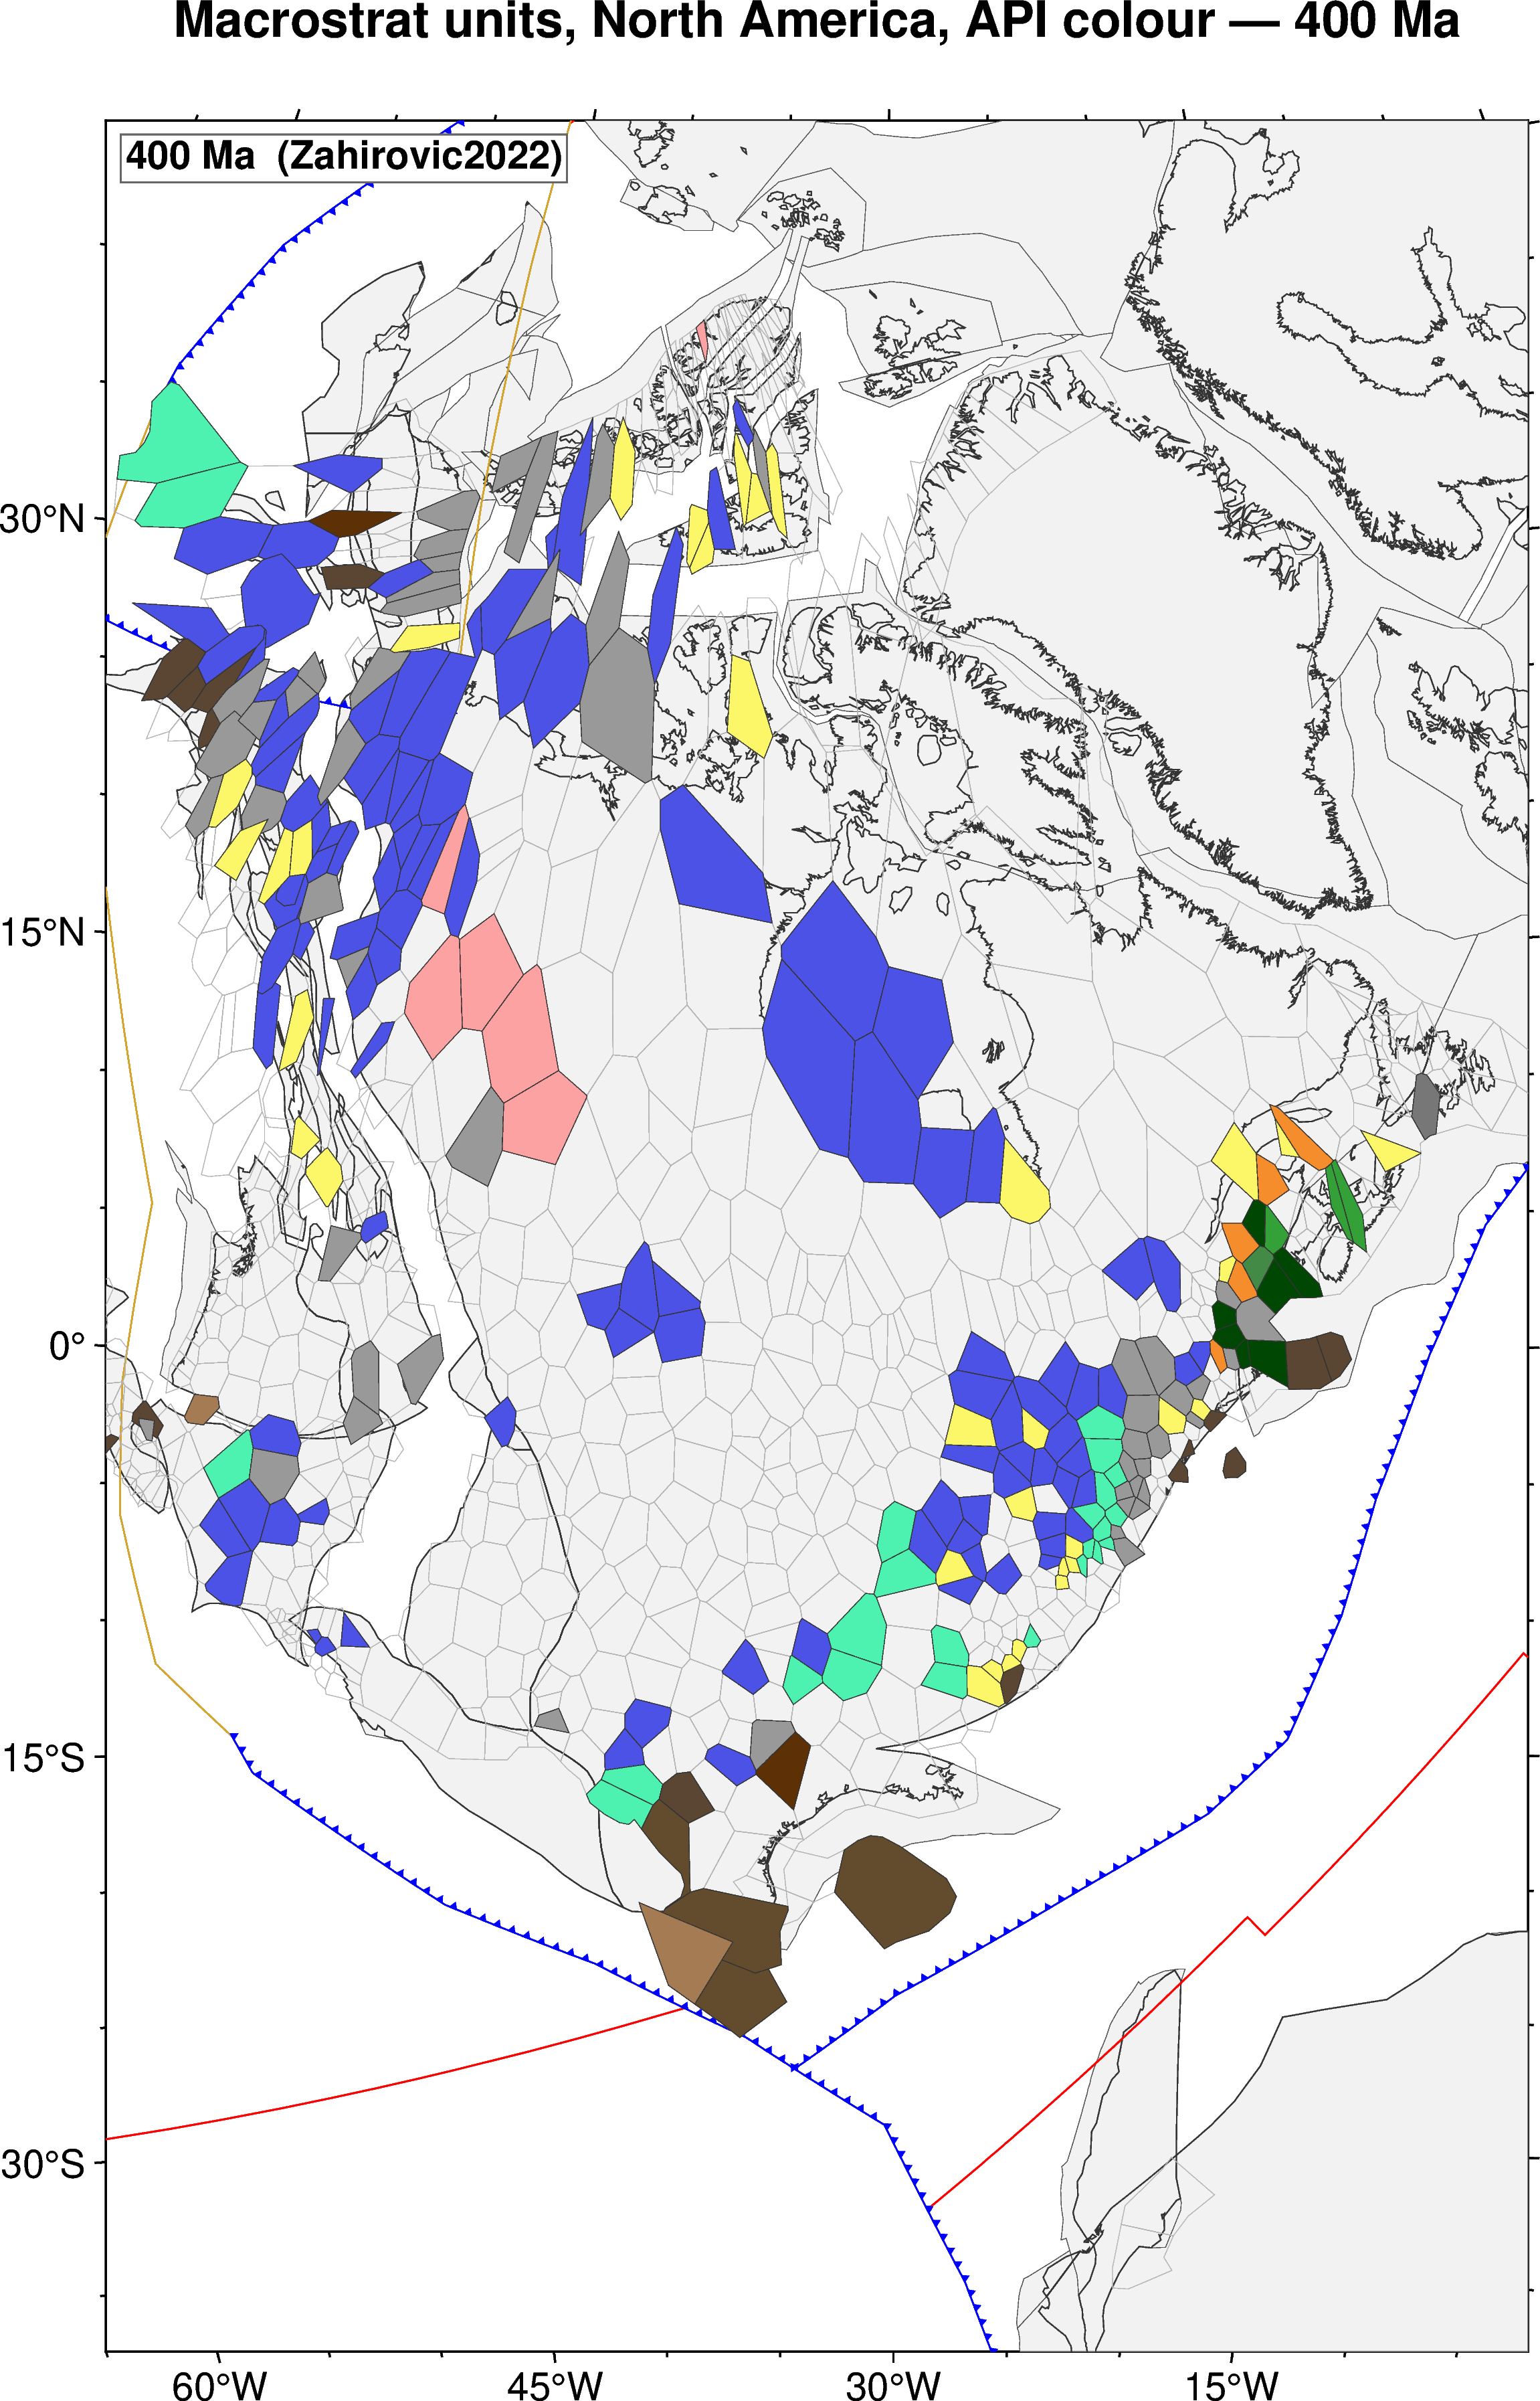

In [8]:
# Cell 7 — group-by-fill plotting (no Figure.choropleth dependency)
def draw_columns(fig, columns, fill="fill", pen="0.2p,gray20"):
    """Fill each column with its own colour or pattern.

    Groups rows sharing an identical fill value into one `fig.plot` call per
    group, rather than one call per row.
    """
    for fill_value, group in columns.groupby(fill):
        fig.plot(data=group[["geometry"]], fill=fill_value, pen=pen)
    return fig


fig = regional_basemap(f"Macrostrat units, North America, API colour — {AGE:.0f} Ma")
fig.plot(data=reconstructed_cols, pen="0.2p,gray70")
draw_columns(fig, units_colored_by_api)
time_stamp(fig)
fig.show(width=750)

### What this map shows

Macrostrat's own per-unit `color` field, one flat colour per column — a first semblance of a paleogeologic map. It's serviceable but coarse: `color` is a representative single colour per lithology class (limestone-blue, shale-grey, sandstone-yellow, …), which throws away any information about a column having a *mixture* of lithologies. Next we do better.

## 6. Mixed lithology colours

Columns often hold several overlapping units, and each unit can itself list multiple lithologies with proportions. [Macrostrat's own stratigraphic column viewer](https://dev.macrostrat.org/columns/337) blends lithology colours proportionally rather than picking one dominant class — we port that approach here, pulling lithology colours from Macrostrat's [Lithologies API](https://macrostrat.org/api/v2/defs/lithologies).

This is a direct Python port of [`flattenLithologies` / `getMixedColorForData`](https://github.com/UW-Macrostrat/web-components/blob/main/packages/column-views/src/units/colors.ts) from Macrostrat's own `column-views` web component: pool each column's `lith` arrays across its units — dividing each unit's contribution by the unit count, then summing entries that share a `lith_id` — then average the resulting lithology colours weighted by those proportions.

In [9]:
# Cell 8 — pooled per-column lithology lists + lithology colour lookup
lithologies = pd.DataFrame(get_macrostrat_data("defs/lithologies", all=1))
lith_colors = lithologies.set_index("lith_id")["color"]
print(f"{len(lithologies)} lithology definitions loaded")


def flatten_lithologies(unit_liths):
    """Pool `lith` arrays across a column's units, merging shared lith_ids.

    Port of `flattenLithologies`: each unit contributes 1/n of the total, so
    a lithology present in every unit outweighs one appearing in only one.
    """
    n_units = len(unit_liths)
    pooled = {}
    for liths in unit_liths:
        for lith in liths:
            prop = (lith.get("prop") or 0) / n_units
            if prop <= 0:
                continue
            entry = pooled.setdefault(
                lith["lith_id"],
                {"lith_id": lith["lith_id"], "name": lith["name"], "prop": 0.0},
            )
            entry["prop"] += prop
    return sorted(pooled.values(), key=lambda lith: -lith["prop"])


def column_lithologies(units):
    """One pooled, proportion-sorted lithology list per column."""
    return (
        units.groupby("col_id")["lith"]
        .apply(list)
        .apply(flatten_lithologies)
        .rename("lith")
    )

214 lithology definitions loaded


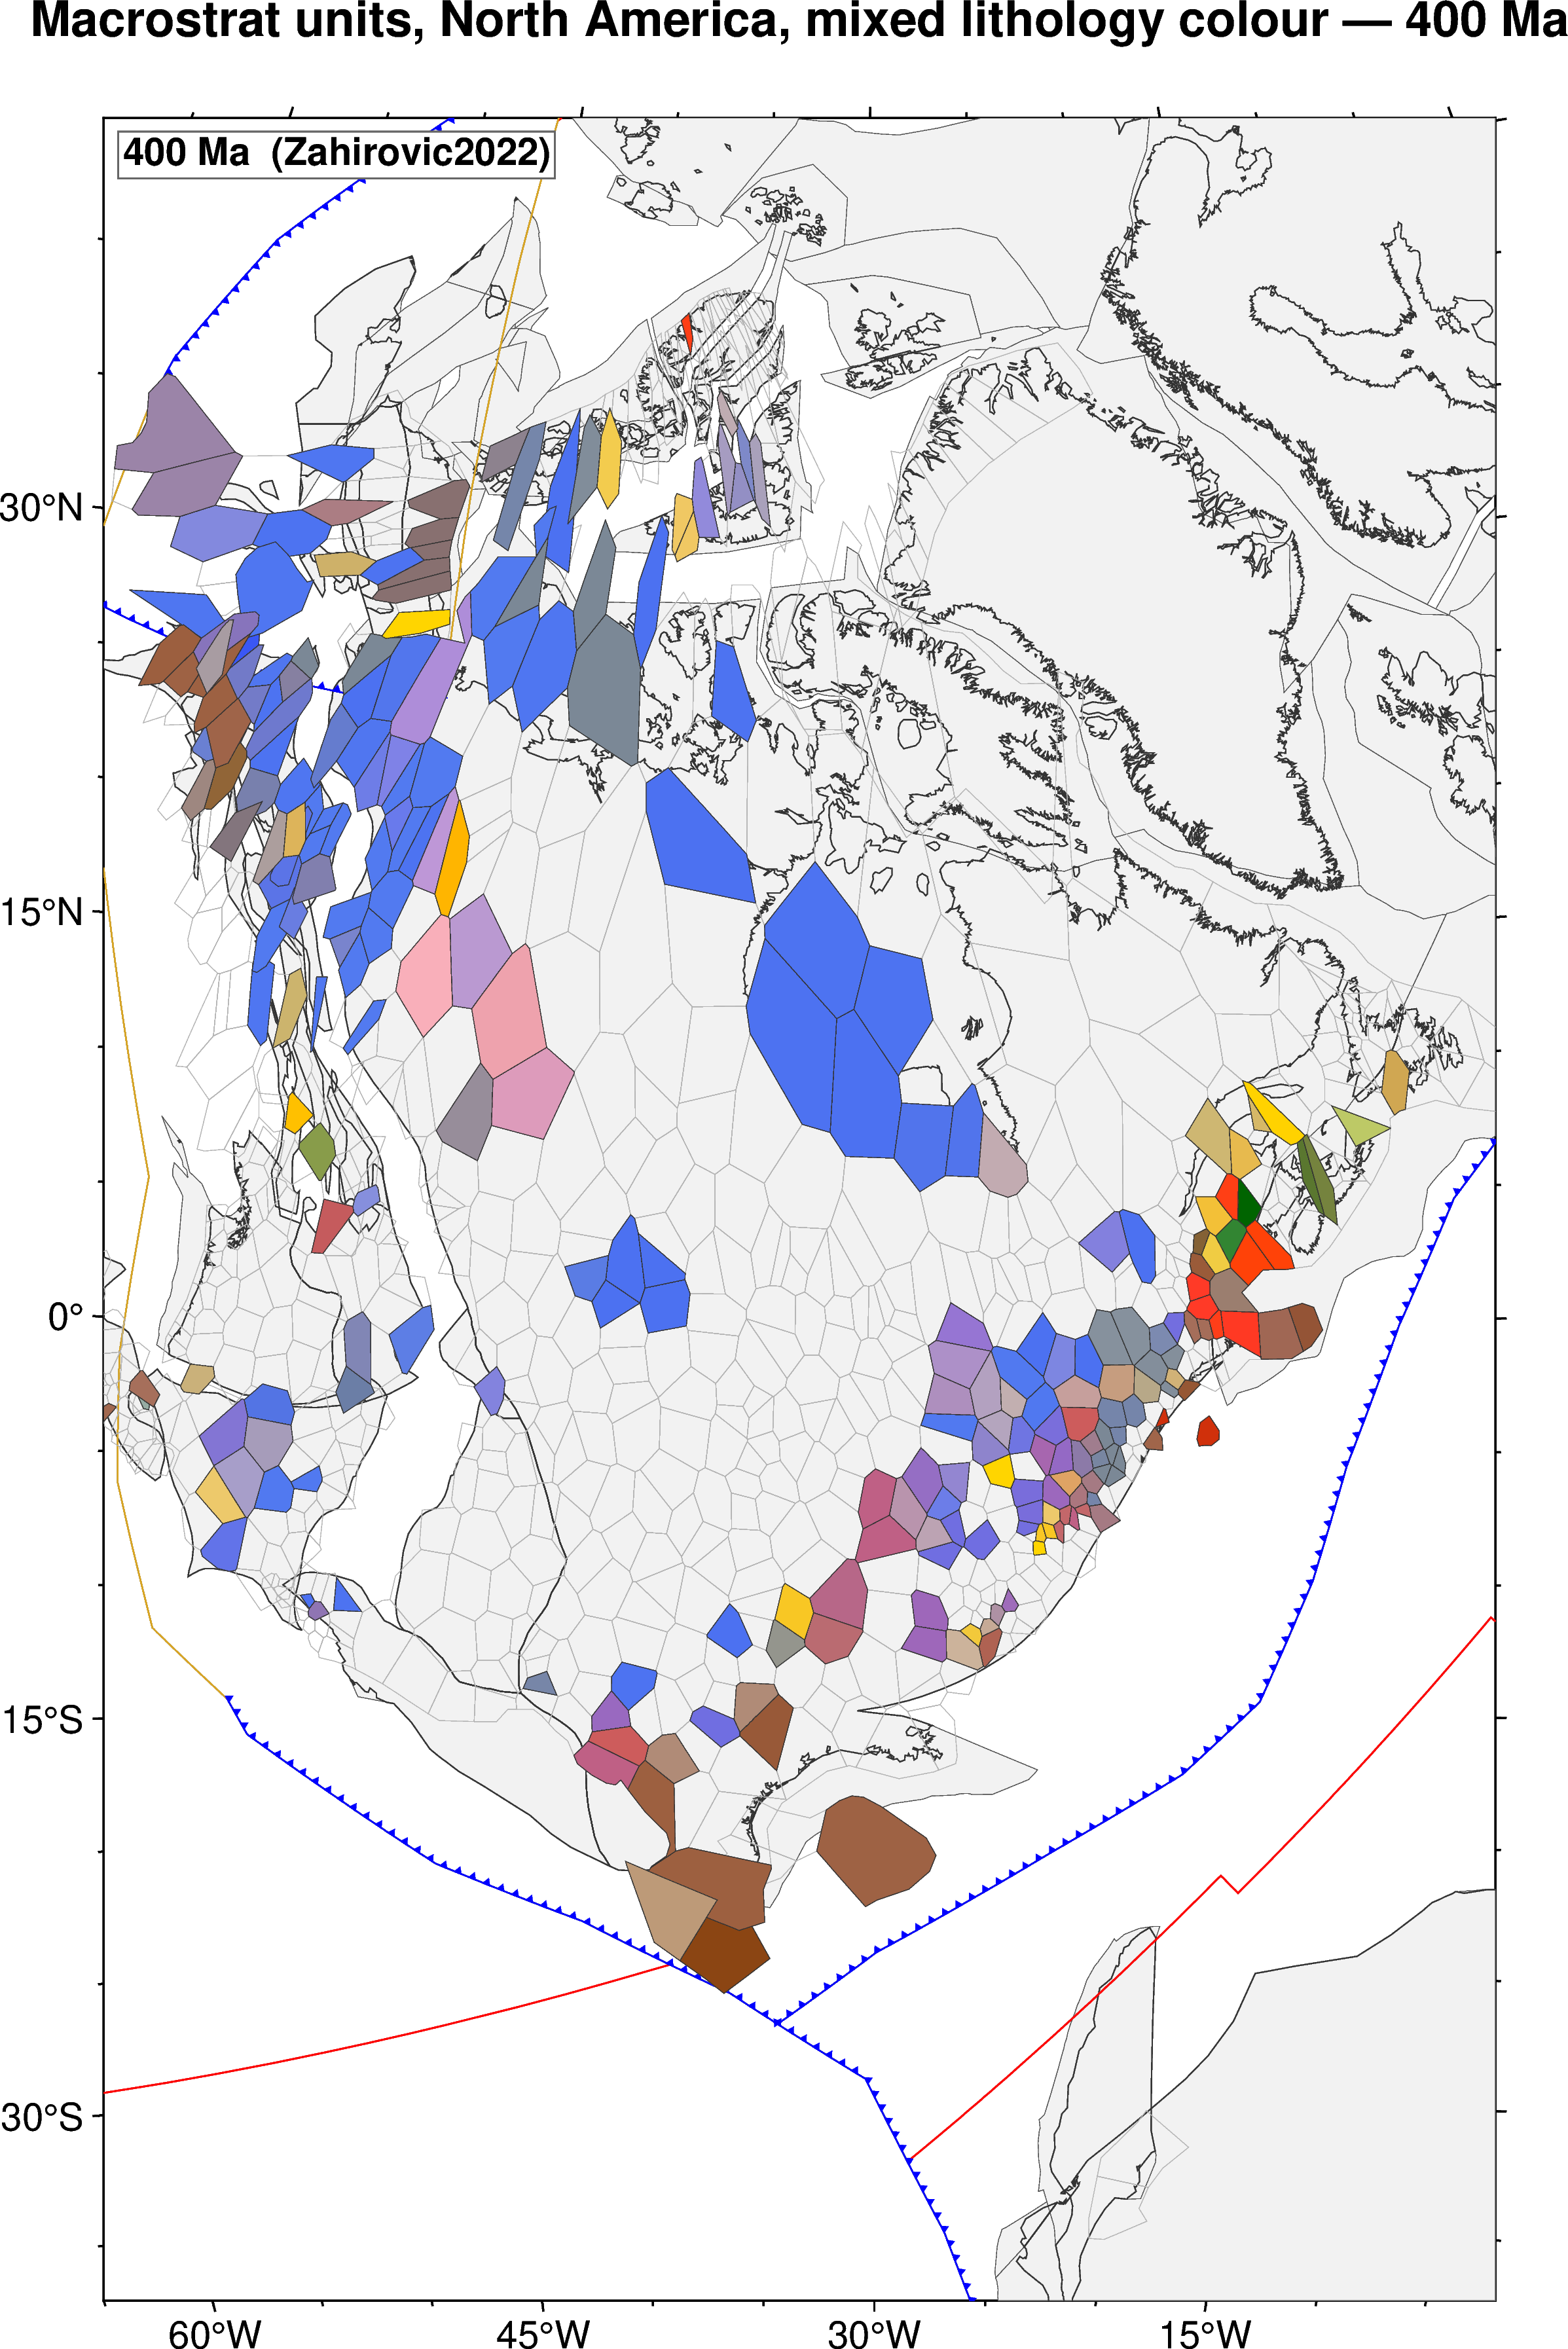

In [10]:
# Cell 9 — colour mixing (coloraide) + the mixed-colour map
def as_hex(color):
    """coloraide Color -> an uppercase hex string GMT will accept."""
    return color.convert("srgb").to_string(hex=True, upper=True)


def adjust(color, lightness=None, saturation=1.0):
    """Set HSL lightness and scale HSL saturation.

    Scaling saturation compensates for the wash-out that averaging several
    lithology colours together tends to produce.
    """
    adjusted = Color(color)
    if saturation != 1.0:
        adjusted = adjusted.set("hsl.s", lambda s: min(1.0, s * saturation))
    if lightness is not None:
        adjusted = adjusted.set("hsl.l", lightness)
    return as_hex(adjusted)


def mixed_color(liths, lightness=None, saturation=1.0):
    """Lithology colours averaged by proportion, as `getMixedColorForData` does."""
    blended = Color.average(
        [lith_colors[lith["lith_id"]] for lith in liths],
        [lith["prop"] for lith in liths],
        space="srgb-linear",
    )
    return adjust(blended, lightness=lightness, saturation=saturation)


columns_with_liths = reconstructed_cols.merge(
    column_lithologies(na_units), on="col_id"
)
columns_with_liths["fill"] = columns_with_liths["lith"].apply(mixed_color)

fig = regional_basemap(
    f"Macrostrat units, North America, mixed lithology colour — {AGE:.0f} Ma"
)
fig.plot(data=reconstructed_cols, pen="0.2p,gray70")
draw_columns(fig, columns_with_liths)
time_stamp(fig)
fig.show(width=750)

### What this map shows

Every column now carries a colour blended across its whole recorded lithology mixture, weighted by the proportion each lithology contributes — a richer, more informative signal than the single-lithology API colour above, at the cost of losing the crisp, immediately-recognisable colour-per-rock-type legend.

## 7. Lithology pattern fills

Macrostrat's web viewer layers [FGDC pattern swatches](https://davenquinn.com/projects/geologic-patterns) on top of colour to give lithology extra visual weight. GMT ships its own library of [predefined pattern swatches](https://docs.generic-mapping-tools.org/latest/reference/predefined-patterns.html) (including several geological ones), so we can reproduce that idea with no added dependency — a hand-built index maps common Macrostrat lithology names to GMT pattern numbers below.

In [11]:
# Cell 10 — Macrostrat lithology name -> GMT pattern number
LITH_PATTERNS = {
    # sedimentary
    "limestone": 20,      # brick
    "dolomite": 21,        # slanted brick
    "dolostone": 21,
    "carbonate": 20,
    "marble": 20,
    "shale": 6,             # horizontal rules
    "mudstone": 25,         # broken horizontal rules
    "claystone": 25,
    "argillite": 25,
    "siltstone": 24,        # fine broken rules
    "sandstone": 30,        # stipple
    "arkose": 30,
    "greywacke": 31,
    "conglomerate": 62,      # pebbles
    "gravel": 62,
    "breccia": 61,           # angular clasts
    "chert": 69,             # irregular blobs
    "gypsum": 26,
    "anhydrite": 26,
    "coal": 15,
    # igneous
    "granite": 29,           # plus signs
    "granodiorite": 29,
    "diorite": 71,           # bold plus signs
    "gabbro": 71,
    "igneous": 71,
    "volcanic": 49,          # filled triangles
    "rhyolite": 48,          # open triangles
    "basalt": 49,
    "andesite": 48,
    "tuff": 47,
    # metamorphic
    "schist": 11,            # diagonal rules
    "phyllite": 25,
    "slate": 24,
    "gneiss": 22,            # crinkled lines
    "quartzite": 13,         # fine crosshatch
    "amphibolite": 12,
    "metamorphic": 14,       # crosshatch
    "mylonite": 23,
}


def pattern_for_lithology(lith):
    """GMT pattern number for a lithology, or None if we have nothing sensible."""
    name = (lith.get("name") or "").lower()
    return LITH_PATTERNS.get(name)

GMT's fill syntax for a pattern is `p<n>+r<dpi>+f<foreground>+b<background>`. We ink the pattern in a darkened version of the column's mixed colour over a pale version of the same colour — averaging several lithology colours pulls the blend toward grey, and lightening it for the pattern background washes it out further, so we scale saturation back up to keep rock types visually distinguishable.

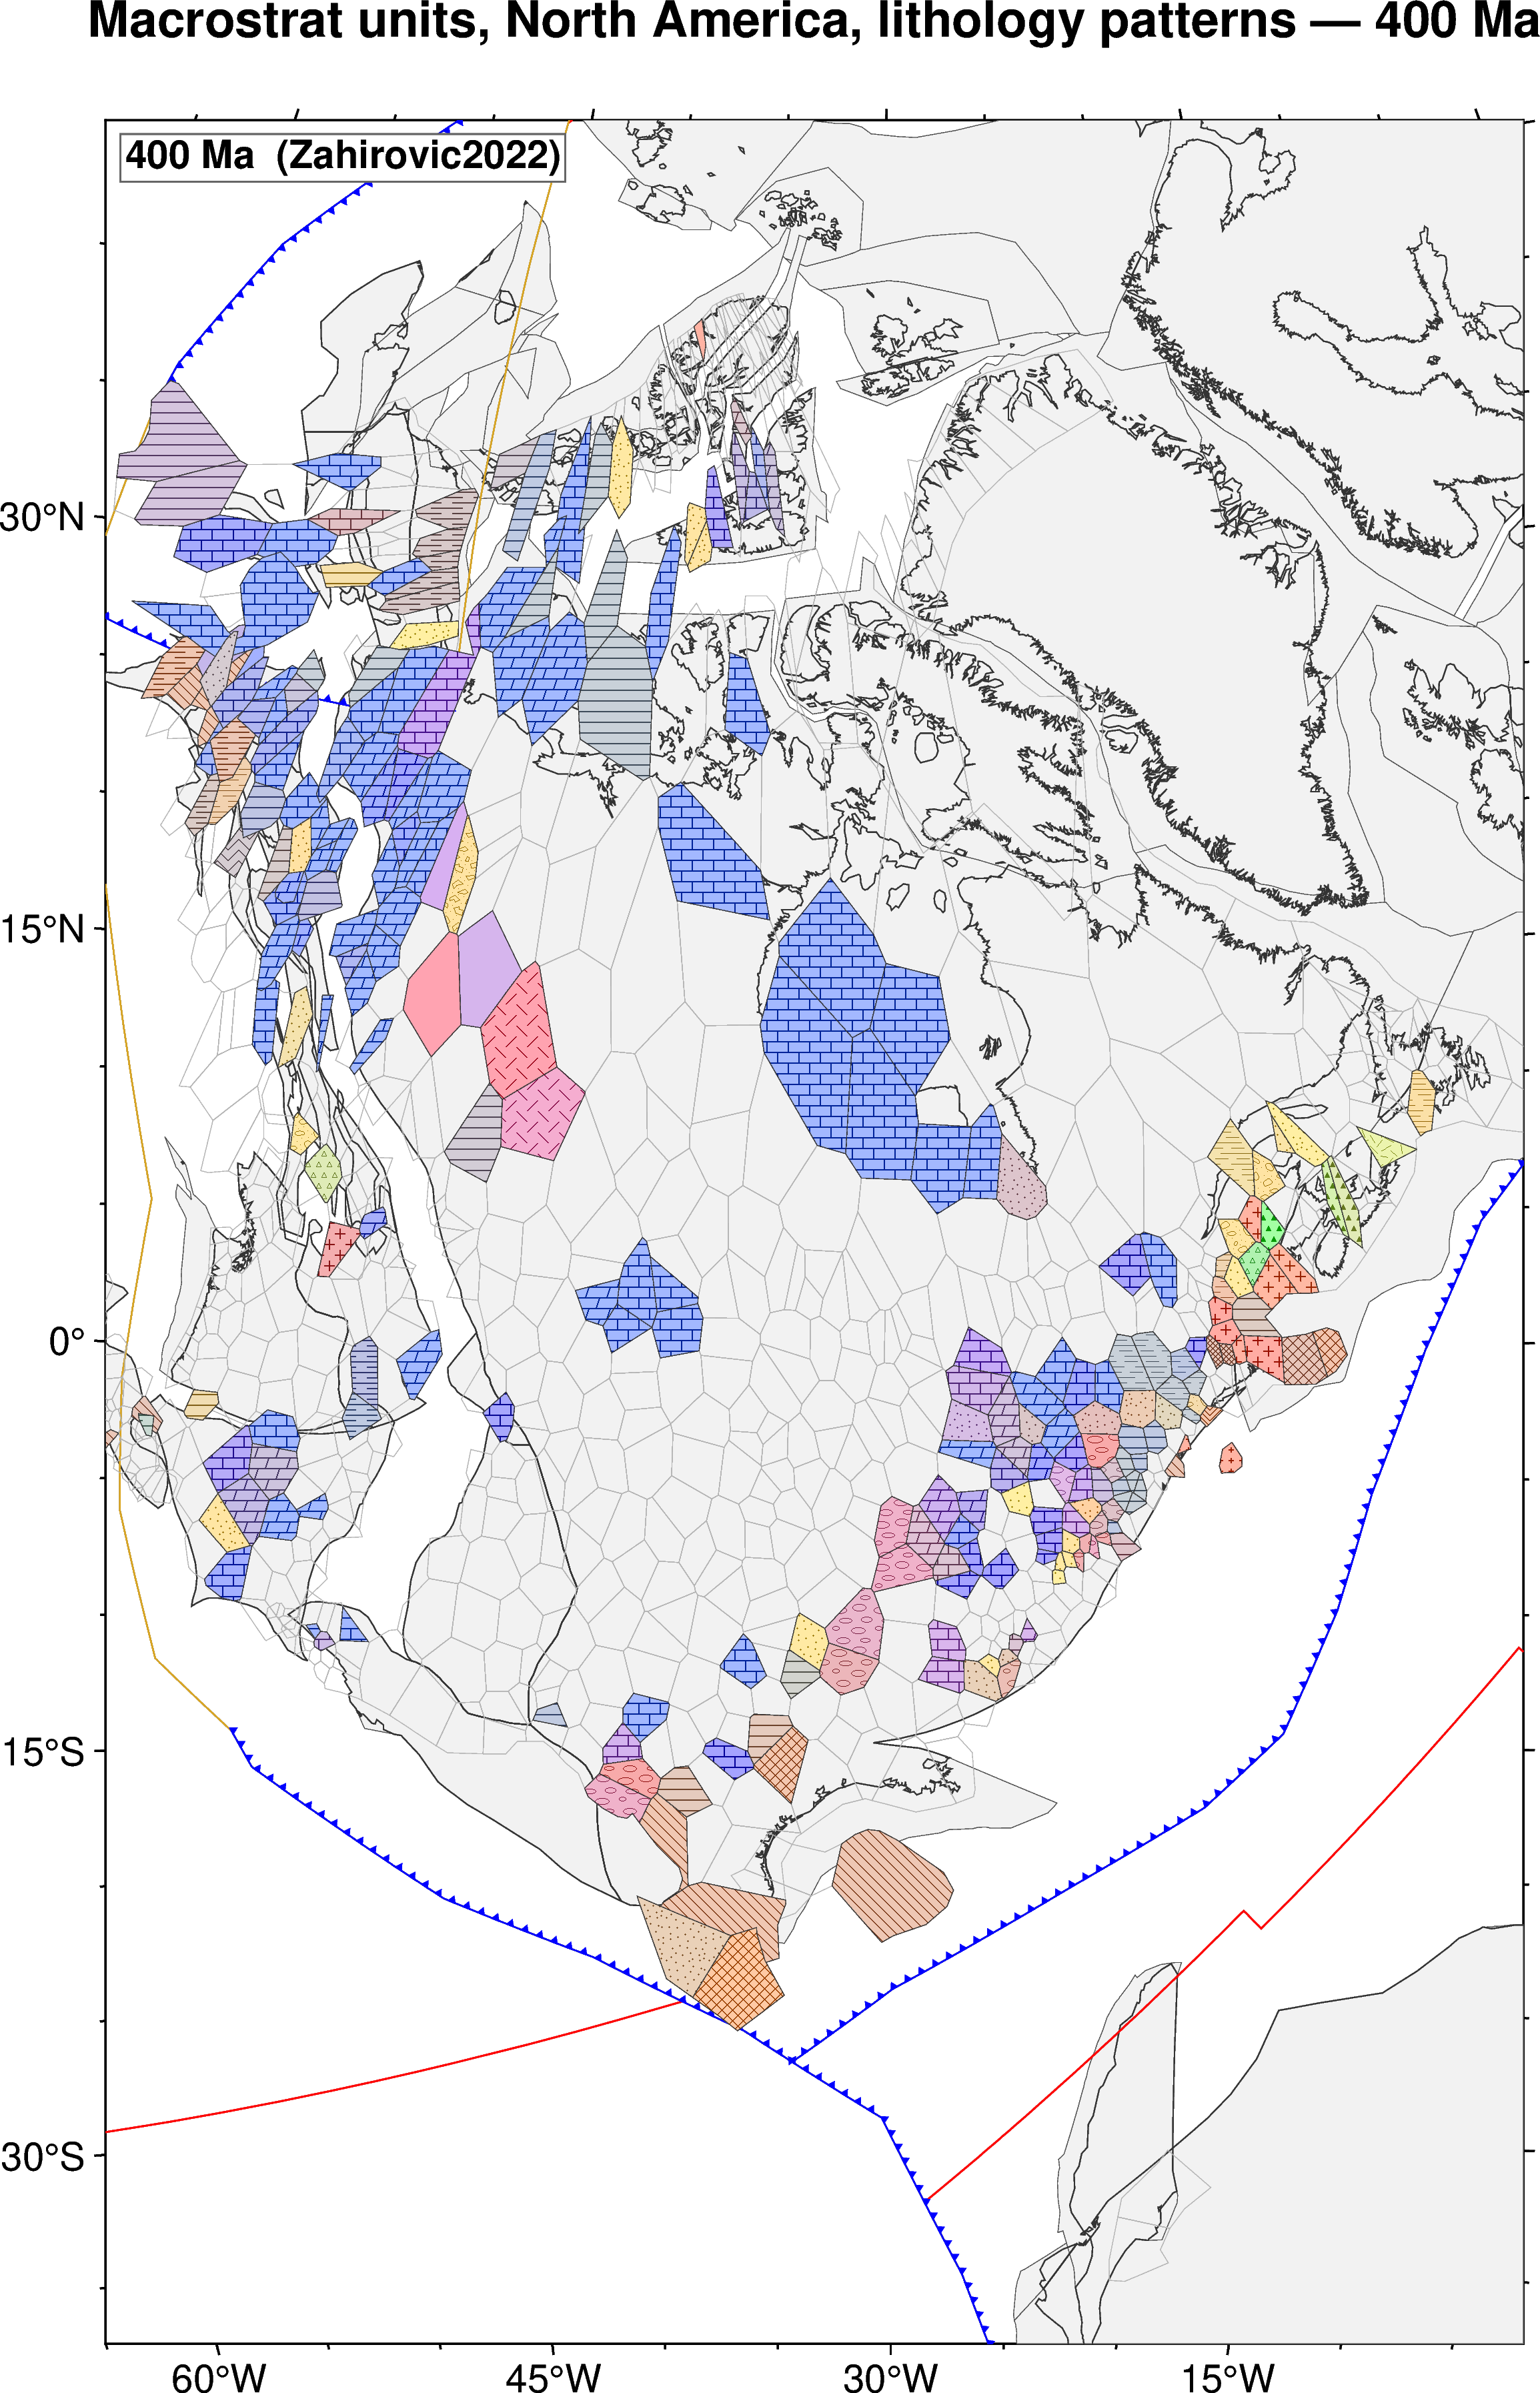

In [12]:
# Cell 11 — pattern fills keyed to dominant lithology + final map
_dpi = 300


def lithology_fill(color, lith):
    """`lith`'s pattern, inked over a pale version of `color`."""
    background = adjust(color, lightness=0.82, saturation=1.6)
    pattern = pattern_for_lithology(lith)
    if pattern is None:
        return background
    ink = adjust(color, lightness=0.30, saturation=1.6)
    return f"p{pattern}+r{_dpi}+f{ink}+b{background}"


def pattern_fill(liths):
    """A GMT pattern fill keyed on the column's dominant lithology.

    `flatten_lithologies` sorts by proportion, so `liths[0]` is dominant.
    """
    return lithology_fill(mixed_color(liths), liths[0])


patterned = columns_with_liths.assign(
    fill=columns_with_liths["lith"].apply(pattern_fill)
)

fig_pattern = regional_basemap(
    f"Macrostrat units, North America, lithology patterns — {AGE:.0f} Ma"
)
fig_pattern.plot(data=reconstructed_cols, pen="0.2p,gray70")
draw_columns(fig_pattern, patterned)
time_stamp(fig_pattern)
fig_pattern.show(width=750)

### What this map shows

The richest of the three stylings: pattern ornament for the dominant lithology, ink colour still carrying the mixed-lithology hue. Compare this against the two maps above — the pattern reads at a glance ("that's a sandstone-dominated column") while the underlying colour still communicates the mixture GMT patterns alone can't show.

## 8. Pattern key

A standalone legend mapping each lithology name that actually appears as a column's *dominant* lithology in this run to its pattern swatch, so the map above is readable without cross-referencing `LITH_PATTERNS`.

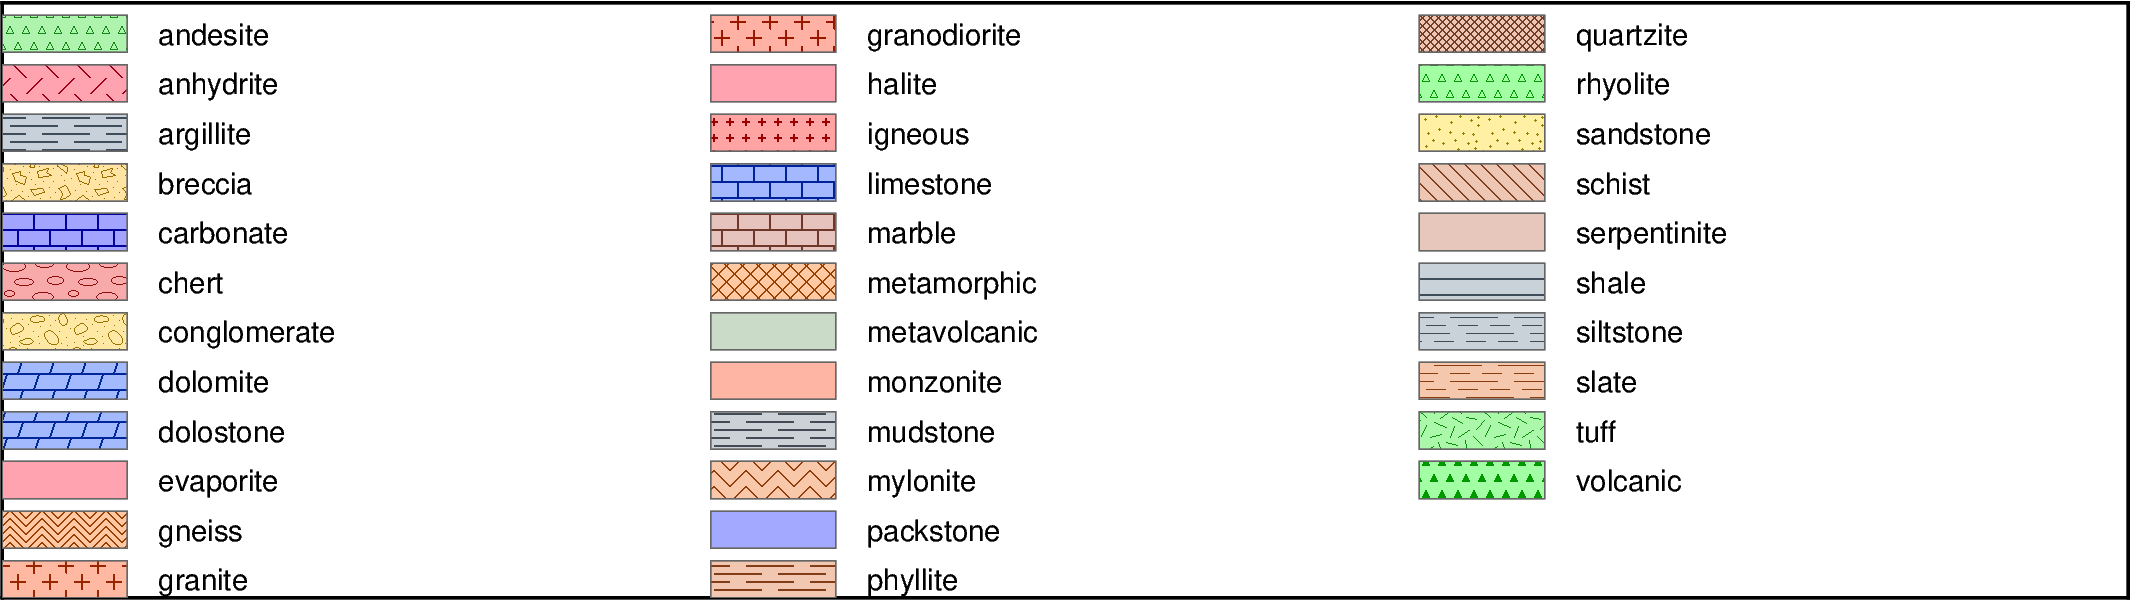

In [13]:
# Cell 12 — pattern key
used_liths = {}
for liths in patterned["lith"]:
    dominant = liths[0]
    used_liths.setdefault(dominant["name"], dominant["lith_id"])

entries = sorted(used_liths.items())
n_rows = -(-len(entries) // 3)  # ceil division, 3 columns of swatches

fig_key = pygmt.Figure()
fig_key.basemap(
    region=[0, 3 * 3.4, 0, n_rows * 0.6],
    projection=f"X18c/{n_rows * 0.42}c",
    frame=0,   # bare panel, no axes/ticks — this is a legend, not a map
)
for i, (name, lith_id) in enumerate(entries):
    x0 = (i // n_rows) * 3.4
    x1 = x0 + 0.6
    y0 = (n_rows - (i % n_rows) - 1) * 0.6
    y1 = y0 + 0.45
    # The lithology's own colour, not any one column's blend.
    fill = lithology_fill(lith_colors[lith_id], {"name": name, "lith_id": lith_id})
    fig_key.plot(x=[x0, x1, x1, x0, x0], y=[y0, y0, y1, y1, y0],
                 fill=fill, pen="0.3p,gray40", close=True)
    fig_key.text(x=x1 + 0.15, y=y0 + 0.22, text=name,
                 font="7p,Helvetica,black", justify="ML")
fig_key.show(width=750)

## Extend this

- **Change the region.** Set `PROJECT_ID` to another Macrostrat project ID to style a different part of the world — §4's region is derived automatically from the reconstruction, so no hardcoded bounds need updating.
- **Show the accreted terranes too.** §4 deliberately frames on the dominant-plate columns (cratonic Laurentia) and crops most western-margin terranes that hadn't yet accreted at 400 Ma. Widen `pad_x` / `pad_y` in §4, or union `core_cols.total_bounds` with `reconstructed_cols.total_bounds`, to see the full dispersal of present-day "North America" fragments across their true 400 Ma positions.
- **Change the age.** Slide `AGE` to any time Macrostrat has coverage for the chosen project — try `AGE = 0` to see the present-day styling with no reconstruction step at all, or push into deeper time with `MODEL_NAME = "Merdith2021"` (0–1000 Ma) rather than the 0–410 Ma Zahirovic 2022 default.
- **Keep every qualifying unit, not just one per column.** §5's `drop_duplicates` keeps this notebook simple by picking one unit per column; a fuller treatment would blend *all* qualifying units' lithologies per column, weighted by however you choose to combine multiple stratigraphic intervals in one age window.
- **Animate through time.** Wrap §3–§7 in a loop over a range of `AGE` values and assemble the frames into a GIF, following the pattern in **T06**.
- **Cross-reference against T45.** **T45 — Macrostrat sedimentary units in paleo-position** answers a narrower scientific question (mapping the Great Unconformity via unit centroids) with a simpler per-point styling; this notebook demonstrates the fuller column-footprint + lithology-styling toolkit that T45's approach could be extended with.

Notebooks that build directly on this one: **T01** (the GPlately + pyGMT plumbing this notebook assumes), **T45** (a narrower, complementary Macrostrat application).

## References

- [UW-Macrostrat / GPlately + pyGMT demo](https://github.com/UW-Macrostrat/gplately-pygmt-demo) — the notebook this tutorial adapts, including its own `paleo_map.py` (marimo) source and lithology-styling approach.
- Peters, S.E., Husson, J.M. & Czaplewski, J. (2018). Macrostrat: A platform for geological data integration and deep-time Earth crust research. *Geochem. Geophys. Geosys.* 19, 1393-1409. https://doi.org/10.1029/2018GC007467
- Quinn, D., Czaplewski, J., Husson, J.M. & Peters, S.E. (2024). New visualization approaches for stratigraphic column data using Macrostrat. *Geoscience Data Journal* 11, 597-608. https://doi.org/10.1002/gdj3.189
- [Macrostrat API v2](https://macrostrat.org/api/v2) — the source of every dataset used in this notebook (columns, units, lithology definitions).
- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geosci. Data J.* 11, 3-10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J., Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679420
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochem. Geophys. Geosys.* 20, 5556-5564. https://doi.org/10.1029/2019GC008515